In [13]:
import os
import numpy as np
import nbtlib
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter

sns.set_theme()


BUILDS_PATH = 'H:/Documents/projets/MinecraftBuildGen/archive (3)/processed_builds/processed_builds'

### Global

In [2]:
filenames = os.listdir(BUILDS_PATH)

print(f'Total Files: {len(filenames)}')

extensions = [f.split('.')[-1] for f in filenames]

counts = Counter(extensions)
print(counts)

Total Files: 39327
Counter({'schem': 28235, 'h5': 11092})


### Schem Files

In [3]:
versions = []
dataversions = []
heights = []
lengths = []
widths = []
volumes = []
palettemaxs = []
blockdata_count = []
blockentities_count = []
no_blockentities_tag_count = 0

filenames_schem = [f for f in filenames if f.split('.')[-1] == 'schem']

for fn in tqdm(filenames_schem):
    try:
        fp = os.path.join(BUILDS_PATH, fn)
        schem = nbtlib.load(fp)
    except:
        continue
    
    versions.append(schem['Version'])
    dataversions.append(schem['DataVersion'])
    heights.append(schem['Height'])
    lengths.append(schem['Length'])
    widths.append(schem['Width'])
    volumes.append(schem['Height'] * schem['Length'] * schem['Width'])
    palettemaxs.append(schem['PaletteMax'])
    blockdata_count.append(len(schem['BlockData']))
    if 'BlockEntities' in schem:
        blockentities_count.append(len(schem['BlockEntities']))
    else:
        blockentities_count.append(0)
        no_blockentities_tag_count += 1


100%|██████████| 28235/28235 [21:04<00:00, 22.33it/s]  


In [ ]:
# No blockentities count

print(no_blockentities_tag_count)

4


In [ ]:
# schem versions

versions_count = Counter(versions)
print(versions_count)

Counter({Int(2): 28235})


#### Volumes

In [81]:
volumes_arr = np.array(volumes)

In [82]:
# remove outliers
volumes_arr = volumes_arr[volumes_arr<10e8]
print(volumes_arr.max())
print(f'removed count : {len(volumes) - len(volumes_arr)}')

996147200
removed count : 46


<Axes: >

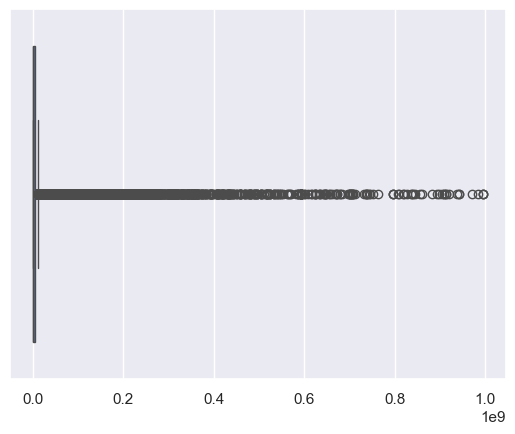

In [ ]:
sns.boxplot(x=volumes_arr)

#### Palettemaxs

In [84]:
palettemaxs_arr = np.array(palettemaxs)

In [87]:
# remove outliers
palettemaxs_arr = palettemaxs_arr[palettemaxs_arr<2000]
print(palettemaxs_arr.max())
print(f'removed count : {len(palettemaxs) - len(palettemaxs_arr)}')

1751
removed count : 9


<Axes: >

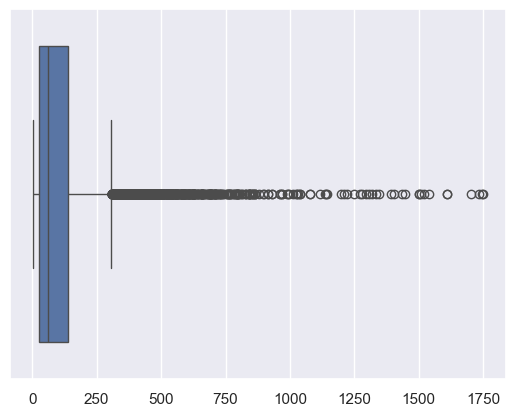

In [88]:

sns.boxplot(x=palettemaxs_arr)

#### BlockEntities

In [93]:
blockentities_count_arr = np.array(blockentities_count)

In [94]:
# remove outliers
blockentities_count_arr = blockentities_count_arr[blockentities_count_arr<10e8]
print(blockentities_count_arr.max())
print(f'removed count : {len(blockentities_count) - len(blockentities_count_arr)}')

0
removed count : 0


<Axes: >

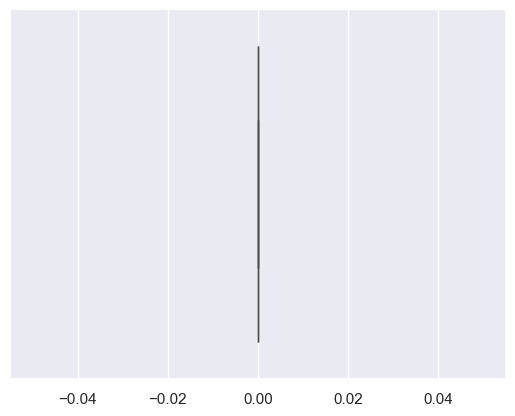

In [95]:

sns.boxplot(x=blockentities_count_arr)